In [14]:
import mne

In [15]:
raw = mne.io.read_raw_edf("SC4002E0-PSG.edf", preload=True)
print(raw)

Extracting EDF parameters from SC4002E0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 8489999  =      0.000 ... 84899.990 secs...


C:\Users\cbamm\AppData\Local\Temp\ipykernel_20056\896827236.py:1: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf("SC4002E0-PSG.edf", preload=True)
C:\Users\cbamm\AppData\Local\Temp\ipykernel_20056\896827236.py:1: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf("SC4002E0-PSG.edf", preload=True)
C:\Users\cbamm\AppData\Local\Temp\ipykernel_20056\896827236.py:1: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf("SC4002E0-PSG.edf", preload=True)


<RawEDF | SC4002E0-PSG.edf, 7 x 8490000 (84900.0 s), ~453.4 MiB, data loaded>


In [16]:
annotations = mne.read_annotations("SC4002EC-Hypnogram.edf")
print(annotations)

<Annotations | 152 segments: Movement time (1), Sleep stage 1 (32), Sleep ...>


In [17]:
print(set(annotations.description) )

{np.str_('Movement time'), np.str_('Sleep stage 1'), np.str_('Sleep stage R'), np.str_('Sleep stage 3'), np.str_('Sleep stage W'), np.str_('Sleep stage 2'), np.str_('Sleep stage ?'), np.str_('Sleep stage 4')}


In [18]:
raw.pick_channels(['EEG Fpz-Cz'])

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


<RawEDF | SC4002E0-PSG.edf, 1 x 8490000 (84900.0 s), ~64.8 MiB, data loaded>

In [22]:
#raw.plot(duration=30, n_channels=1)

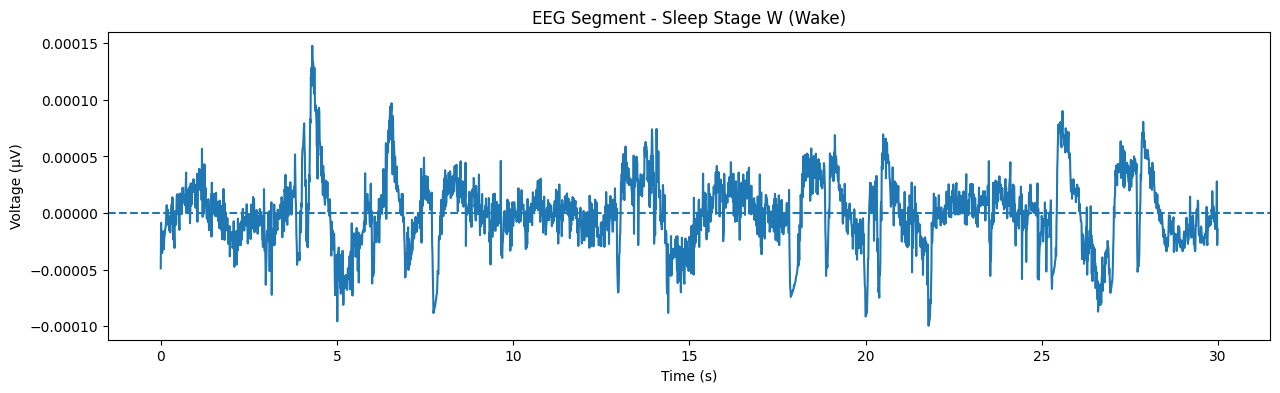

Sleep stage: Sleep stage W


In [50]:
import matplotlib.pyplot as plt

data, times = raw[:]

plt.figure(figsize=(15, 4))  # wider horizontal
plt.plot(times[:3000], data[0][:3000])
plt.xlabel("Time (s)")
plt.ylabel("Voltage (µV)")
plt.title("EEG Segment - Sleep Stage W (Wake)")
plt.axhline(0, linestyle='--')
plt.savefig('wake.png')
plt.show()

start_time = 0  # change if your plot starts elsewhere

for desc, onset, duration in zip(annotations.description,
                                 annotations.onset,
                                 annotations.duration):
    if onset <= start_time < onset + duration:
        print("Sleep stage:", desc)
        break

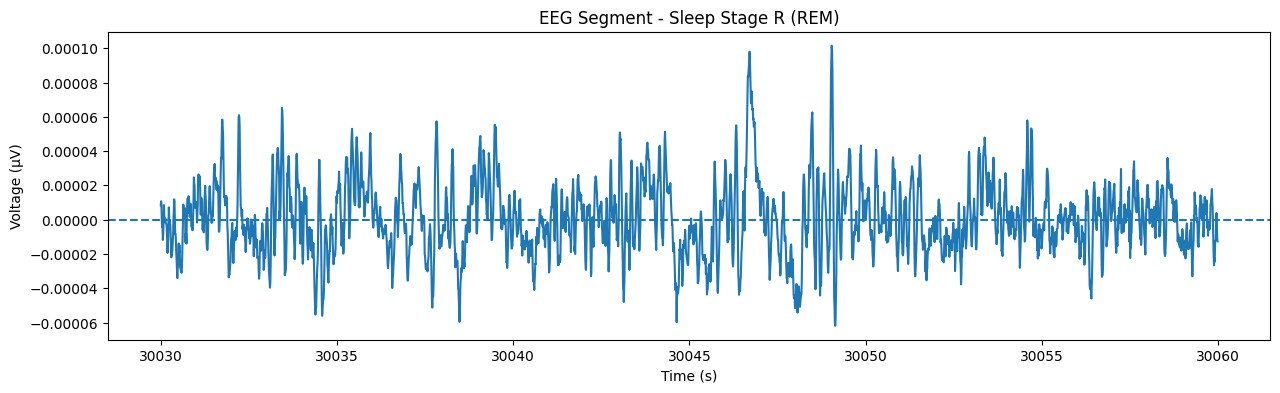

Sleep stage: Sleep stage R


In [51]:
import matplotlib.pyplot as plt

data, times = raw[:]
sfreq = raw.info['sfreq']

start_time = 30030
start_sample = int(start_time * sfreq)
end_sample = start_sample + int(30 * sfreq)

plt.figure(figsize=(15, 4))
plt.plot(times[start_sample:end_sample],
         data[0][start_sample:end_sample])
plt.xlabel("Time (s)")
plt.ylabel("Voltage (µV)")
plt.title("EEG Segment - Sleep Stage R (REM)")
plt.axhline(0, linestyle='--')
plt.savefig('rem.png')
plt.show()

for desc, onset, duration in zip(annotations.description,
                                 annotations.onset,
                                 annotations.duration):
    if onset <= start_time < onset + duration:
        print("Sleep stage:", desc)
        break

In [54]:
sfreq = raw.info['sfreq']
print('Sampling Frequency:', sfreq, 'Hz')

Sampling Frequency: 100.0 Hz
